<a href="https://colab.research.google.com/github/Shayan-ss7/MACFE-Firmware-2026/blob/main/Assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1



## Question 1:
{method, implementation, answer}

Examine the value of sparse matricies by comparing the approximate computational efficiencies of sparse and dense solvers (on the same system). Use the %timeit function to approximate the complexity.

HINT: Refer to the lecture notes on how to generate, store, and apply sparse solvers.  

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

sizes = [250, 500, 1000, 2000]

dense_times = []
sparse_times = []

for n in sizes:
    # Build the tridiagonal matrix from the lecture
    A = np.zeros((n, n))
    np.fill_diagonal(A, 2)
    np.fill_diagonal(A[1:], -1)
    np.fill_diagonal(A[:, 1:], -1)

    # Same matrix, stored sparsely
    A_sparse = csr_matrix(A)
    b = np.ones(n)

    # Measure the time per solve
    dense = %timeit -o -q -r 3 np.linalg.solve(A, b)
    sparse = %timeit -o -q -r 3 spsolve(A_sparse, b)

    dense_times.append(dense.average)
    sparse_times.append(sparse.average)

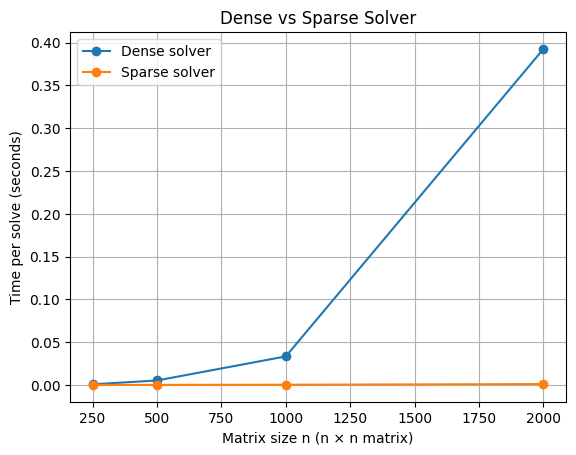

In [3]:
plt.plot(sizes, dense_times, "o-", label="Dense solver")
plt.plot(sizes, sparse_times, "o-", label="Sparse solver")

plt.xlabel("Matrix size n (n × n matrix)")
plt.ylabel("Time per solve (seconds)")
plt.title("Dense vs Sparse Solver")

plt.legend()
plt.grid(True)
plt.show()

## Question 2

Consider the truss:

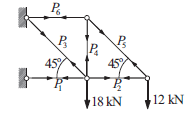


### 2a) Write the linear system for the tensions $P_i$ as equations and in matrix form
{answer}

Let c = 1/√2.
Positive forces mean tension; negative forces mean compression.
All forces are in kN.

The equations are:

-P1 + P2 - cP3 = 0

cP3 + P4 = 18

-P2 - cP5 = 0

cP5 = 12

cP5 - P6 = 0

-P4 - cP5 = 0

Matrix form: A x = b

A = [
  
    [-1,  1, -c,  0,  0,  0],
    [ 0,  0,  c,  1,  0,  0],
    [ 0, -1,  0,  0, -c,  0],
    [ 0,  0,  0,  0,  c,  0],
    [ 0,  0,  0,  0,  c, -1],
    [ 0,  0,  0, -1, -c,  0]
]

x and b are column vectors:

x = [P1, P2, P3, P4, P5, P6]

b = [0, 18, 0, 12, 0, 0]


### 2b) Solve for $P_i$ using LU decomposition and substitution.
{method, answer}

### 2c)  Double the loads (18 kN and 12 kN) and solve for $P_i$ again *without refactoring*.
{answer}

## Question 3

Consider the matrix:

$$ A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

## 3a) Calculate the condition number of A
{answer}

## 3b) Let's use a preconditioner matrix $P$ to improve the condition number of the product $P^{-1} A$. Give 2 examples of $P$ that improve the condition number.

Can you identify the 'perfect' preconditioner? (Consider the easiest matrix to solve!)
{answer, answer}